# Bermudan option pricing
### Polynomial and neural network regression

Longstaff–Schwartz with two interchangeable continuation regressors: a polynomial basis
and a one-hidden-layer network. The learned exercise policies are compared on independent paths.

Notation: `M` paths, `d` assets, `N` exercise intervals with dates $t_0,\dots,t_N$.
Paths have shape `(M, N+1, d)`. All cashflows are discounted to time zero.

Run all cells in order. Results are saved after every repetition in `results/results_<case>_<M_TRAIN>.pt`:
rerunning resumes an interrupted study, and reloads a finished one without recomputing it.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

DEVICE = "cpu"   # "cuda" also works
SEED = 20260919

## 1. Market model and payoffs

Exact lognormal transitions between exercise dates. For a row of independent standard
normals, `normal @ L.T` has correlation matrix $LL^\top=\Gamma$.

In [2]:
class BlackScholesModel:
    def __init__(self, S0, r, sigma, delta=0.0, rho=0.0, T=1.0, N=10):
        self.S0 = np.atleast_1d(np.asarray(S0, dtype=float))
        self.d = self.S0.size
        self.sigma = np.full(self.d, sigma, dtype=float)
        self.delta = np.full(self.d, delta, dtype=float)
        self.r, self.T, self.N = float(r), float(T), int(N)
        self.correlation = np.full((self.d, self.d), float(rho))
        np.fill_diagonal(self.correlation, 1.0)
        self.L = np.linalg.cholesky(self.correlation)
        self.times = np.linspace(0.0, self.T, self.N + 1)
        self.discount = np.exp(-self.r * self.times)

    def simulate(self, M, seed):
        """Prices at t_0, ..., t_N, shape (M, N+1, d)."""
        rng = np.random.default_rng(seed)
        dt = self.T / self.N
        drift = (self.r - self.delta - 0.5 * self.sigma**2) * dt
        paths = np.empty((M, self.N + 1, self.d), dtype=np.float32)
        paths[:, 0] = self.S0
        state = np.tile(self.S0, (M, 1))
        for n in range(1, self.N + 1):
            normal = rng.standard_normal((M, self.d)) @ self.L.T
            state *= np.exp(drift + self.sigma * np.sqrt(dt) * normal)
            paths[:, n] = state
        return paths


class Option:
    def __init__(self, K):
        self.K = float(K)


class Put(Option):
    def payoff(self, x):
        return np.maximum(self.K - np.asarray(x, dtype=float)[..., 0], 0.0)


class GeometricBasketPut(Option):
    def payoff(self, x):
        basket = np.exp(np.log(np.asarray(x, dtype=float)).mean(axis=-1))
        return np.maximum(self.K - basket, 0.0)


class MaxCall(Option):
    def payoff(self, x):
        return np.maximum(np.asarray(x, dtype=float).max(axis=-1) - self.K, 0.0)

## 2. Regressors

Both regressors implement `fit(x, Y, initial)` and `predict(x)` in monetary units.
Internally, $\widetilde x=x/K-1$ and $\widetilde Y=Y/K$, so that
$\widehat c_n(x)=K f(x/K-1)$.

### Polynomial regression

All monomials of total degree at most $p$ in $\widetilde x$: $q=\binom{d+p}{p}$ coefficients.
Each monomial of order $k$ is built as a monomial of order $k-1$ times one variable.
The normal equations are accumulated over blocks of paths,
$\Phi^\top\Phi=\sum_k\Phi_k^\top\Phi_k$ and $\Phi^\top y=\sum_k\Phi_k^\top y_k$,
so the full design matrix is never stored. The columns are equilibrated (unit diagonal)
and the system is solved by Cholesky. Forming $\Phi^\top\Phi$ squares the condition
number: Section 5 compares this solver with a direct least-squares solve.

In [3]:
class PolynomialRegressor:
    def __init__(self, d, K, degree, block_entries=10_000_000):
        self.K, self.degree = K, degree
        # Column i >= 1 is column parents[i-1] times variable variables[i-1].
        # Variable indices never decrease, so x1*x2 and x2*x1 are not both built.
        self.parents, self.variables = [], []
        previous = [(0, 0)]          # (column, smallest variable allowed next); column 0 is the constant
        n_columns = 1
        for order in range(degree):
            current = []
            for column, first in previous:
                for j in range(first, d):
                    self.parents.append(column)
                    self.variables.append(j)
                    current.append((n_columns, j))
                    n_columns += 1
            previous = current
        self.n_parameters = n_columns
        self.block_rows = max(1, block_entries // n_columns)

    def design(self, x):
        scaled = np.asarray(x, dtype=float) / self.K - 1.0
        Phi = np.empty((len(scaled), self.n_parameters), order="F")   # filled column by column
        Phi[:, 0] = 1.0
        for column, (parent, j) in enumerate(zip(self.parents, self.variables), start=1):
            Phi[:, column] = Phi[:, parent] * scaled[:, j]
        return Phi

    def fit(self, x, Y, initial=None):
        q = self.n_parameters
        if len(x) < q:
            raise ValueError(f"Only {len(x)} ITM paths for {q} coefficients.")
        y = np.asarray(Y, dtype=float) / self.K
        G, b = np.zeros((q, q)), np.zeros(q)
        for start in range(0, len(x), self.block_rows):
            Phi = self.design(x[start:start + self.block_rows])
            G += Phi.T @ Phi
            b += Phi.T @ y[start:start + self.block_rows]
        scale = np.sqrt(np.diag(G))
        G_scaled = G / np.outer(scale, scale)
        L = np.linalg.cholesky(G_scaled)          # raises LinAlgError if not numerically positive definite
        u = np.linalg.solve(L, b / scale)
        self.coefficients = np.linalg.solve(L.T, u) / scale
        eigenvalues = np.linalg.eigvalsh(G_scaled)
        self.condition = float(eigenvalues[-1] / eigenvalues[0])
        return self

    def predict(self, x):
        prediction = np.empty(len(x))
        for start in range(0, len(x), self.block_rows):
            stop = start + self.block_rows
            prediction[start:stop] = self.K * (self.design(x[start:stop]) @ self.coefficients)
        return prediction

### Neural regression

`fc1 -> LeakyReLU(0.3) -> fc2`, with a linear output. PyTorch stores `fc1.weight` with
shape `(h, d)`, transposed relative to $XW^{[1]}+b^{[1]}$.

One epoch is one pass over the in-the-money paths in shuffled mini-batches of size $B$,
that is $\lceil |I_n|/B\rceil$ Adam updates. A network starting from random weights is trained
for `epochs_first` epochs; a network warm-started from the next date's weights is trained for
`epochs_warm` epochs, with a fresh optimizer. Each date keeps its own fitted network.

In [4]:
class ContinuationNetwork(nn.Module):
    def __init__(self, d, width):
        super().__init__()
        self.fc1 = nn.Linear(d, width)
        self.activation = nn.LeakyReLU(negative_slope=0.3)
        self.fc2 = nn.Linear(width, 1)
        # This network could also be written with nn.Sequential.

    def forward(self, x):
        a1 = self.activation(self.fc1(x))
        return self.fc2(a1).squeeze(-1)


class NeuralRegressor:
    def __init__(self, d, K, width, epochs_first, epochs_warm, batch_size=256,
                 learning_rate=1e-3, seed=0, device="cpu"):
        self.K, self.batch_size, self.learning_rate = K, batch_size, learning_rate
        self.epochs_first, self.epochs_warm = epochs_first, epochs_warm
        self.seed, self.device = seed, device
        torch.manual_seed(seed)
        self.network = ContinuationNetwork(d, width).to(device)
        self.n_parameters = sum(p.numel() for p in self.network.parameters())

    def fit(self, x, Y, initial=None):
        if initial is not None:
            self.network.load_state_dict(initial.network.state_dict())   # warm start
        epochs = self.epochs_first if initial is None else self.epochs_warm
        # The full training set stays on CPU; only the current batch goes to the device.
        inputs = torch.as_tensor(np.asarray(x, dtype=np.float32) / self.K - 1.0)
        targets = torch.as_tensor(np.asarray(Y, dtype=np.float32) / self.K)
        optimizer = torch.optim.Adam(self.network.parameters(), lr=self.learning_rate)
        loss_function = nn.MSELoss()
        generator = torch.Generator().manual_seed(self.seed)
        self.network.train()
        self.n_updates = 0
        for epoch in range(epochs):                           # one pass over the data
            order = torch.randperm(len(inputs), generator=generator)
            for indices in order.split(self.batch_size):      # one update per mini-batch
                xb, yb = inputs[indices].to(self.device), targets[indices].to(self.device)
                optimizer.zero_grad()
                loss = loss_function(self.network(xb), yb)
                loss.backward()
                optimizer.step()
                self.n_updates += 1
        return self

    def predict(self, x, chunk_size=100_000):
        prediction = np.empty(len(x))
        self.network.eval()
        with torch.no_grad():
            for start in range(0, len(x), chunk_size):
                stop = start + chunk_size
                xb = torch.as_tensor(np.asarray(x[start:stop], dtype=np.float32) / self.K - 1.0,
                                     device=self.device)
                prediction[start:stop] = self.K * self.network(xb).cpu().numpy()
        return prediction

## 3. Longstaff–Schwartz

At date $t_n$, `Y` contains the discounted cashflows obtained by continuing and then following
the fitted future policy. Exercise replaces `Y` by the immediate payoff; continuation keeps it.
Only in-the-money paths enter the regression. Validation paths follow the same decisions,
which gives a held-out regression error at each date.

The decision at time zero is fixed during training. `evaluate` applies the frozen policy forwards
on new paths: `tau = 0` is immediate exercise, `tau = N` exercise or worthless expiry at maturity.

In [5]:
def discounted_payoffs(model, option, paths):
    """Z[m, n] = exp(-r t_n) g(S_{t_n}) on path m, shape (M, N+1)."""
    Z = np.empty((len(paths), model.N + 1))
    for n in range(model.N + 1):
        Z[:, n] = model.discount[n] * option.payoff(paths[:, n])
    return Z


class LSMPricer:
    def __init__(self, model, option, make_regressor):
        self.model, self.option, self.make_regressor = model, option, make_regressor

    def fit(self, paths, validation_paths=None):
        Z = discounted_payoffs(self.model, self.option, paths)
        Y = Z[:, -1].copy()
        if validation_paths is not None:
            Z_valid = discounted_payoffs(self.model, self.option, validation_paths)
            Y_valid = Z_valid[:, -1].copy()
        self.regressors = [None] * (self.model.N + 1)
        self.diagnostics = []
        previous = None

        for n in range(self.model.N - 1, 0, -1):
            itm = Z[:, n] > 0
            if not np.any(itm):
                continue                      # no fit: the learned rule always continues here
            regressor = self.make_regressor(n).fit(paths[itm, n], Y[itm], initial=previous)
            self.regressors[n] = regressor
            prediction = regressor.predict(paths[itm, n])
            diagnostic = {"date": n, "itm": int(itm.sum()), "parameters": regressor.n_parameters,
                          "train_mse": float(np.mean((Y[itm] - prediction)**2)),
                          "validation_mse": None,
                          "condition": getattr(regressor, "condition", None),
                          "updates": getattr(regressor, "n_updates", None)}
            exercise = np.zeros(len(paths), dtype=bool)
            exercise[itm] = Z[itm, n] >= prediction
            Y[exercise] = Z[exercise, n]      # target for date n-1

            if validation_paths is not None:
                itm_valid = Z_valid[:, n] > 0
                if np.any(itm_valid):
                    prediction_valid = regressor.predict(validation_paths[itm_valid, n])
                    diagnostic["validation_mse"] = float(
                        np.mean((Y_valid[itm_valid] - prediction_valid)**2))
                    exercise_valid = np.zeros(len(validation_paths), dtype=bool)
                    exercise_valid[itm_valid] = Z_valid[itm_valid, n] >= prediction_valid
                    Y_valid[exercise_valid] = Z_valid[exercise_valid, n]
            self.diagnostics.append(diagnostic)
            previous = regressor

        self.continuation0 = float(Y.mean())
        Z0 = float(self.option.payoff(self.model.S0[None, :])[0])
        self.exercise0 = Z0 > 0 and Z0 >= self.continuation0
        self.training_value = Z0 if self.exercise0 else self.continuation0
        return self

    def evaluate(self, paths):
        Z = discounted_payoffs(self.model, self.option, paths)
        M = len(paths)
        if self.exercise0:
            return Z[:, 0].copy(), np.zeros(M, dtype=int)
        H = Z[:, -1].copy()
        tau = np.full(M, self.model.N, dtype=int)
        alive = np.ones(M, dtype=bool)
        for n in range(1, self.model.N):
            regressor = self.regressors[n]
            if regressor is None:
                continue
            indices = np.flatnonzero(alive & (Z[:, n] > 0))
            if len(indices) == 0:
                continue
            prediction = regressor.predict(paths[indices, n])
            exercised = indices[Z[indices, n] >= prediction]
            H[exercised], tau[exercised], alive[exercised] = Z[exercised, n], n, False
        return H, tau

## 4. Contracts and reference values

The contracts are those of Lapeyre & Lelong (2020, Section 5). Their benchmark for the put
is 11.987. The geometric basket reduces exactly to a scalar Black–Scholes asset, with
$\sigma_G^2=d^{-2}\sigma^\top\Gamma\sigma$ and
$\delta_G=\overline\delta+\tfrac12\overline{\sigma^2}-\tfrac12\sigma_G^2$;
a CRR tree with exercise restricted to the Bermudan dates then gives a numerical reference,
shown at three refinements. For the max-calls, the 95% intervals are those of Becker et al.
quoted by Lapeyre & Lelong. The prices tabulated by Lapeyre & Lelong are estimated on
training paths, so they are not directly comparable with our independent test values.

In [6]:
CASES = {
    "put_1d": dict(model=dict(S0=[100], r=0.10, sigma=0.25, T=1.0, N=10),
                   payoff="put", K=110, degrees=[2, 3, 4], literature=None),
    "geometric_10d": dict(model=dict(S0=[100] * 10, r=0.05, sigma=0.2, rho=0.2, T=1.0, N=10),
                          payoff="geometric_put", K=100, degrees=[2, 3], literature=None),
    "max_call_5d": dict(model=dict(S0=[100] * 5, r=0.05, sigma=0.2, delta=0.1, T=3.0, N=9),
                        payoff="max_call", K=100, degrees=[2, 3, 4, 5, 6], literature=(26.14, 26.17)),
    "max_call_50d": dict(model=dict(S0=[100] * 50, r=0.05, sigma=0.2, delta=0.1, T=3.0, N=9),
                         payoff="max_call", K=100, degrees=[1, 2], literature=(69.56, 69.95)),
}
# nn128 and nn128_long differ only by the number of epochs after a warm start.
NETWORKS = [dict(name="nn32", width=32, epochs_first=10, epochs_warm=1),
            dict(name="nn128", width=128, epochs_first=10, epochs_warm=1),
            dict(name="nn128_long", width=128, epochs_first=10, epochs_warm=5)]
BATCH_SIZE, LEARNING_RATE = 256, 1e-3


def make_case(name):
    case = CASES[name]
    option_class = {"put": Put, "geometric_put": GeometricBasketPut, "max_call": MaxCall}[case["payoff"]]
    return BlackScholesModel(**case["model"]), option_class(case["K"])


def candidates_for(name):
    polynomials = [{"name": f"poly{p}", "family": "polynomial", "degree": p}
                   for p in CASES[name]["degrees"]]
    networks = [dict(network, family="neural") for network in NETWORKS]
    return polynomials + networks

In [7]:
def normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(torch.tensor(x / np.sqrt(2.0))).item())


def european_put(S0, K, r, delta, sigma, T):
    d1 = (np.log(S0 / K) + (r - delta + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * normal_cdf(-d2) - S0 * np.exp(-delta * T) * normal_cdf(-d1)


def crr_put(S0, K, r, delta, sigma, T, N, substeps, european=False):
    """CRR tree with `substeps` steps per exercise interval; exercise only at the N+1 dates."""
    steps = N * substeps
    dt = T / steps
    up = np.exp(sigma * np.sqrt(dt))
    probability = (np.exp((r - delta) * dt) - 1 / up) / (up - 1 / up)
    j = np.arange(steps + 1)
    values = np.maximum(K - S0 * up**(2 * j - steps), 0.0)
    for k in range(steps - 1, -1, -1):
        values = np.exp(-r * dt) * ((1 - probability) * values[:-1] + probability * values[1:])
        if not european and k % substeps == 0:
            spot = S0 * up**(2 * np.arange(k + 1) - k)
            values = np.maximum(values, K - spot)
    return float(values[0])


def scalar_put_parameters(model):
    """Initial value, dividend yield and volatility of the geometric mean of the assets."""
    G0 = float(np.exp(np.log(model.S0).mean()))
    variance = float(model.sigma @ model.correlation @ model.sigma / model.d**2)
    delta = float(model.delta.mean() + 0.5 * np.mean(model.sigma**2) - 0.5 * variance)
    return G0, delta, np.sqrt(variance)


REFERENCES = {}
for name in CASES:
    model, option = make_case(name)
    if isinstance(option, MaxCall):
        continue
    G0, delta, sigma = scalar_put_parameters(model)
    REFERENCES[name] = {substeps: crr_put(G0, option.K, model.r, delta, sigma, model.T, model.N, substeps)
                        for substeps in (500, 1000, 2000)}
    print(name, "CRR, substeps per exercise interval:", REFERENCES[name])

put_1d CRR, substeps per exercise interval: {500: 11.987979854106344, 1000: 11.987348591105642, 2000: 11.987482630051629}
geometric_10d CRR, substeps per exercise interval: {500: 2.929719340056565, 1000: 2.9296852595323695, 2000: 2.92975295780998}


## 5. Numerical checks

In [8]:
# The eight paths of the worked example in Longstaff & Schwartz (2001): reference data.
ls_paths = np.array([
    [1.09, 1.08, 1.34], [1.16, 1.26, 1.54], [1.22, 1.07, 1.03],
    [0.93, 0.97, 0.92], [1.11, 1.56, 1.52], [0.76, 0.77, 0.90],
    [0.92, 0.84, 1.01], [0.88, 1.22, 1.34],
])
ls_paths = np.concatenate([np.ones((8, 1)), ls_paths], axis=1)[..., None]
ls_model = BlackScholesModel(S0=1.0, r=0.06, sigma=0.2, T=3.0, N=3)   # sigma unused: paths are given
ls_option = Put(1.1)
ls_pricer = LSMPricer(ls_model, ls_option,
                      lambda n: PolynomialRegressor(1, ls_option.K, degree=2)).fit(ls_paths)
H, tau = ls_pricer.evaluate(ls_paths)
np.testing.assert_allclose(H.mean(), ls_pricer.training_value, atol=1e-12)
np.testing.assert_allclose(H.mean(), 0.1144, atol=5e-5)
print("Eight-path example:", H.mean(), "exercise indices:", tau)

Eight-path example: 0.11443433004505696 exercise indices: [3 3 3 1 3 1 1 1]


In [9]:
# Known polynomial, fitted over ten blocks: checks the features, the solver and the scaling.
rng = np.random.default_rng(12)
x = rng.uniform(70, 130, size=(100, 2))
u = x / 100 - 1
Y = 100 * (0.2 + u[:, 0] + 0.3 * u[:, 1]**2 - u[:, 0] * u[:, 1])
poly = PolynomialRegressor(2, 100, degree=2, block_entries=60).fit(x, Y)
np.testing.assert_allclose(poly.predict(x), Y, rtol=1e-8, atol=1e-8)
counts = [PolynomialRegressor(d, 100, p).n_parameters for d, p in [(1, 3), (5, 4), (50, 2), (50, 3)]]
assert counts == [4, 126, 1326, 23426], counts

# Network interface and parameter count (d + 2) h + 1.
network = ContinuationNetwork(50, 32)
assert network(torch.zeros(7, 50)).shape == (7,)
assert sum(p.numel() for p in network.parameters()) == (50 + 2) * 32 + 1

# A European CRR price should approach the Black-Scholes formula.
closed_form = european_put(100, 110, 0.10, 0.0, 0.25, 1.0)
tree = crr_put(100, 110, 0.10, 0.0, 0.25, 1.0, 10, substeps=200, european=True)
np.testing.assert_allclose(tree, closed_form, atol=0.02)
print("Polynomial and network checks passed; European tree error:", tree - closed_form)

Polynomial and network checks passed; European tree error: 0.000838785916108975


In [10]:
# Simulated moments, and backward/forward accounting on the training paths.
check_model = BlackScholesModel([100, 100], r=0.05, sigma=0.2, rho=0.4, N=5)
check_paths = check_model.simulate(20_000, seed=42)
log_return = np.log(check_paths[:, -1].astype(float) / check_model.S0)
expected_mean = (check_model.r - check_model.delta - 0.5 * check_model.sigma**2) * check_model.T
mean_se = check_model.sigma * np.sqrt(check_model.T / len(check_paths))
assert np.all(np.abs(log_return.mean(axis=0) - expected_mean) < 5 * mean_se)
print("Sample log-return correlation (target 0.4):", np.corrcoef(log_return.T)[0, 1])

check_option = GeometricBasketPut(110)
check_pricer = LSMPricer(check_model, check_option,
                         lambda n: PolynomialRegressor(2, 110, degree=2)).fit(check_paths)
check_H, check_tau = check_pricer.evaluate(check_paths)
np.testing.assert_allclose(check_H.mean(), check_pricer.training_value, atol=1e-10)
Z_check = discounted_payoffs(check_model, check_option, check_paths)
np.testing.assert_allclose(check_H, Z_check[np.arange(len(check_paths)), check_tau])
assert np.all(Z_check[np.arange(len(check_paths)), check_tau][check_tau < check_model.N] > 0)
print("Backward/forward accounting agrees.")

Sample log-return correlation (target 0.4): 0.39569809992832916
Backward/forward accounting agrees.


In [11]:
# Blockwise Cholesky against a direct least-squares solve, on in-the-money states of the bases
# with the largest condition numbers observed in the study, at the first and the last regression
# dates. The sample size matches the smallest training budget, where conditioning is worst;
# the direct solve needs the whole design matrix in memory.
SOLVER_CHECKS = [("put_1d", 4), ("max_call_5d", 4), ("max_call_5d", 5), ("max_call_5d", 6),
                 ("max_call_50d", 2)]
for name, degree in SOLVER_CHECKS:
    model, option = make_case(name)
    paths = model.simulate(10_000, seed=[SEED, 99])
    Z = discounted_payoffs(model, option, paths)
    for n in (1, model.N - 1):
        itm = Z[:, n] > 0
        x, Y = paths[itm, n], Z[itm, -1]
        blockwise = PolynomialRegressor(model.d, option.K, degree, block_entries=2_000_000).fit(x, Y)
        Phi = blockwise.design(x)
        direct = option.K * (Phi @ np.linalg.lstsq(Phi, Y / option.K, rcond=None)[0])
        prediction = blockwise.predict(x)
        changed = np.mean((Z[itm, n] >= prediction) != (Z[itm, n] >= direct))
        print(f"{name}, degree {degree}, date {n}: condition {blockwise.condition:.1e}, "
              f"largest prediction gap {np.max(np.abs(prediction - direct)):.1e}, "
              f"changed exercise decisions {changed:.1e}")
        assert changed < 1e-3
del paths, Z, Phi

put_1d, degree 4, date 1: condition 5.6e+04, largest prediction gap 4.8e-12, changed exercise decisions 0.0e+00
put_1d, degree 4, date 9: condition 5.0e+04, largest prediction gap 2.6e-11, changed exercise decisions 0.0e+00
max_call_5d, degree 4, date 1: condition 1.9e+02, largest prediction gap 4.7e-13, changed exercise decisions 0.0e+00
max_call_5d, degree 4, date 8: condition 4.5e+02, largest prediction gap 9.5e-13, changed exercise decisions 0.0e+00
max_call_5d, degree 5, date 1: condition 1.1e+03, largest prediction gap 8.8e-12, changed exercise decisions 0.0e+00
max_call_5d, degree 5, date 8: condition 9.1e+03, largest prediction gap 4.3e-12, changed exercise decisions 0.0e+00
max_call_5d, degree 6, date 1: condition 2.1e+04, largest prediction gap 2.9e-10, changed exercise decisions 0.0e+00
max_call_5d, degree 6, date 8: condition 4.1e+05, largest prediction gap 4.3e-11, changed exercise decisions 0.0e+00
max_call_50d, degree 2, date 1: condition 6.8e+02, largest prediction gap 

## 6. Experiments

In each repetition, the training, validation and test samples are independent and shared by
all candidates. Validation selects one polynomial and one network, before any test path is
simulated. The test paths are generated in blocks: for each policy we accumulate
$\sum_m H^{(m)}$ and $\sum_m (H^{(m)})^2$, and the same for the paired difference
$D^{(m)}=H^{(m)}_{\rm neural}-H^{(m)}_{\rm polynomial}$ of the two selected policies.
Fitting times include the validation diagnostics; they are indicative only.

In [12]:
SELECTED_CASES = ["put_1d", "geometric_10d", "max_call_5d", "max_call_50d"]
M_TRAIN, M_VALID, M_TEST = 100_000, 100_000, 1_000_000
REPETITIONS = 5
TEST_BLOCK = 100_000
IMPLEMENTATION = "2026-09-19"   # change whenever the computational code changes
# Quick trial: e.g. M_TRAIN, M_VALID, M_TEST = 10_000, 10_000, 100_000 and REPETITIONS = 2.


def make_pricer(model, option, config, seed):
    def make_regressor(n):
        if config["family"] == "polynomial":
            return PolynomialRegressor(model.d, option.K, config["degree"])
        return NeuralRegressor(model.d, option.K, config["width"], config["epochs_first"],
                               config["epochs_warm"], BATCH_SIZE, LEARNING_RATE,
                               seed=seed + n, device=DEVICE)
    return LSMPricer(model, option, make_regressor)


def mean_and_se(total, total_squares, M):
    mean = total / M
    return mean, float(np.sqrt((total_squares / M - mean**2) / (M - 1)))


def run_repetition(name, repetition):
    model, option = make_case(name)
    case_index = list(CASES).index(name)
    seed = [SEED, case_index, repetition]                  # train, validation and test streams
    network_seed = SEED + 1000 * case_index + 100 * repetition
    configs = candidates_for(name)
    train = model.simulate(M_TRAIN, seed + [0])
    valid = model.simulate(M_VALID, seed + [1])

    pricers, rows = {}, {}
    for config in configs:
        pricer = make_pricer(model, option, config, network_seed)
        start = time.perf_counter()
        pricer.fit(train, valid)
        fit_seconds = time.perf_counter() - start
        H_valid, _ = pricer.evaluate(valid)
        pricers[config["name"]] = pricer
        rows[config["name"]] = {"family": config["family"], "training_value": pricer.training_value,
                                "validation_value": float(H_valid.mean()), "fit_seconds": fit_seconds,
                                "exercise0": bool(pricer.exercise0), "diagnostics": pricer.diagnostics}
    del train, valid

    selected = {}
    for family in ("polynomial", "neural"):
        names = [config["name"] for config in configs if config["family"] == family]
        selected[family] = max(names, key=lambda candidate: rows[candidate]["validation_value"])

    totals = {key: [0.0, 0.0] for key in list(pricers) + ["difference"]}
    counts = {candidate: np.zeros(model.N + 1, dtype=int) for candidate in pricers}
    start = time.perf_counter()
    for block, first in enumerate(range(0, M_TEST, TEST_BLOCK)):
        test = model.simulate(min(TEST_BLOCK, M_TEST - first), seed + [2, block])
        H = {}
        for candidate, pricer in pricers.items():
            H[candidate], tau = pricer.evaluate(test)
            counts[candidate] += np.bincount(tau, minlength=model.N + 1)
        H["difference"] = H[selected["neural"]] - H[selected["polynomial"]]
        for key, values in H.items():
            totals[key][0] += float(values.sum())
            totals[key][1] += float((values**2).sum())
    evaluation_seconds = time.perf_counter() - start

    for candidate in pricers:
        value, se = mean_and_se(*totals[candidate], M_TEST)
        rows[candidate].update(test_value=value, test_se=se,
                               exercise_counts=counts[candidate].tolist())
    value, se = mean_and_se(*totals["difference"], M_TEST)
    print(f"{name}, repetition {repetition + 1}: "
          f"{selected['polynomial']} {rows[selected['polynomial']]['test_value']:.4f}, "
          f"{selected['neural']} {rows[selected['neural']]['test_value']:.4f}, "
          f"difference {value:+.4f} +/- {1.96 * se:.4f}", flush=True)
    return {"configs": rows, "selected": selected, "difference": {"value": value, "se": se},
            "evaluation_seconds": evaluation_seconds}


def run_case(name):
    path = f"results/results_{name}_{M_TRAIN}.pt"
    settings = {"case": CASES[name], "networks": NETWORKS, "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE, "M_train": M_TRAIN, "M_valid": M_VALID,
                "M_test": M_TEST, "seed": SEED, "test_block": TEST_BLOCK,
                "implementation": IMPLEMENTATION}
    try:
        saved = torch.load(path, weights_only=False)      # our own file: resume or reload
    except FileNotFoundError:
        saved = {"settings": settings, "repetitions": []}
    # Files written before these two fields existed used the values below.
    saved_settings = {"test_block": 100_000, "implementation": "2026-09-19", **saved["settings"]}
    if saved_settings != settings:
        raise ValueError(f"{path} was produced with other settings: rename or delete it.")
    saved["settings"] = settings
    for repetition in range(len(saved["repetitions"]), REPETITIONS):
        saved["repetitions"].append(run_repetition(name, repetition))
        saved["environment"] = {"numpy": np.__version__, "torch": str(torch.__version__),
                                "device": DEVICE}
        torch.save(saved, path)
    return saved

In [13]:
results = {name: run_case(name) for name in SELECTED_CASES}

## 7. Results

Across $R$ repetitions, a quantity is summarized by its mean $\pm\,t_{R-1,0.975}\,s/\sqrt R$.
For the selected difference, this interval includes both retraining variability and test noise;
the within-repetition Monte Carlo standard error is shown separately and is not added to it.

In [14]:
T_QUANTILE = {1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571, 6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262}


def across_repetitions(values):
    """Mean and 95% Student half-width across repetitions."""
    values = np.asarray(values, dtype=float)
    R = len(values)
    half = T_QUANTILE[R - 1] * values.std(ddof=1) / np.sqrt(R) if R > 1 else np.nan
    return values.mean(), half


for name, saved in results.items():
    reps = saved["repetitions"]
    print(f"\n{name}: {len(reps)} repetitions")
    if name in REFERENCES:
        print("  CRR reference:", {k: round(v, 4) for k, v in REFERENCES[name].items()})
    if CASES[name]["literature"] is not None:
        print("  Literature interval:", CASES[name]["literature"])
    print(f"  {'candidate':<12}{'test':>10}{'+/-':>8}{'MC SE':>8}{'training':>10}{'updates':>9}{'fit s':>8}")
    for candidate, first in reps[0]["configs"].items():
        rows = [rep["configs"][candidate] for rep in reps]
        mean, half = across_repetitions([row["test_value"] for row in rows])
        mc_se = np.mean([row["test_se"] for row in rows])
        training = np.mean([row["training_value"] for row in rows])
        if first["family"] == "neural":
            updates = f"{np.mean([sum(dg['updates'] for dg in row['diagnostics']) for row in rows]):.0f}"
        else:
            updates = "--"
        fit = np.median([row["fit_seconds"] for row in rows])
        print(f"  {candidate:<12}{mean:>10.4f}{half:>8.4f}{mc_se:>8.4f}{training:>10.4f}{updates:>9}{fit:>8.1f}")
    mean, half = across_repetitions([rep["difference"]["value"] for rep in reps])
    mc_se = np.mean([rep["difference"]["se"] for rep in reps])
    print(f"  Selected neural - selected polynomial: {mean:+.4f} +/- {half:.4f} (mean MC SE {mc_se:.4f})")
    for family in ("polynomial", "neural"):
        gaps = [rep["configs"][rep["selected"][family]]["training_value"]
                - rep["configs"][rep["selected"][family]]["test_value"] for rep in reps]
        mean, half = across_repetitions(gaps)
        print(f"  Training estimate - test value, selected {family}: {mean:+.4f} +/- {half:.4f}")
    print("  Selected:", [(rep["selected"]["polynomial"], rep["selected"]["neural"]) for rep in reps])


put_1d: 5 repetitions
  CRR reference: {500: 11.988, 1000: 11.9873, 2000: 11.9875}
  candidate         test     +/-   MC SE  training  updates   fit s
  poly2          11.9725  0.0086  0.0094   11.9862       --     0.5
  poly3          11.9872  0.0113  0.0092   11.9994       --     0.4
  poly4          11.9884  0.0112  0.0092   12.0006       --     0.4
  nn32           11.8957  0.0830  0.0091   11.9119     4299     9.7
  nn128          11.7404  0.3952  0.0086   11.7488     4299    12.2
  nn128_long     11.7885  0.1343  0.0090   11.7948    12775    34.6
  Selected neural - selected polynomial: -0.0878 +/- 0.0742 (mean MC SE 0.0037)
  Training estimate - test value, selected polynomial: +0.0122 +/- 0.0153
  Training estimate - test value, selected neural: +0.0134 +/- 0.0179
  Selected: [('poly4', 'nn32'), ('poly4', 'nn32'), ('poly4', 'nn32'), ('poly4', 'nn32'), ('poly4', 'nn128')]

geometric_10d: 5 repetitions
  CRR reference: {500: 2.9297, 1000: 2.9297, 2000: 2.9298}
  candidate       

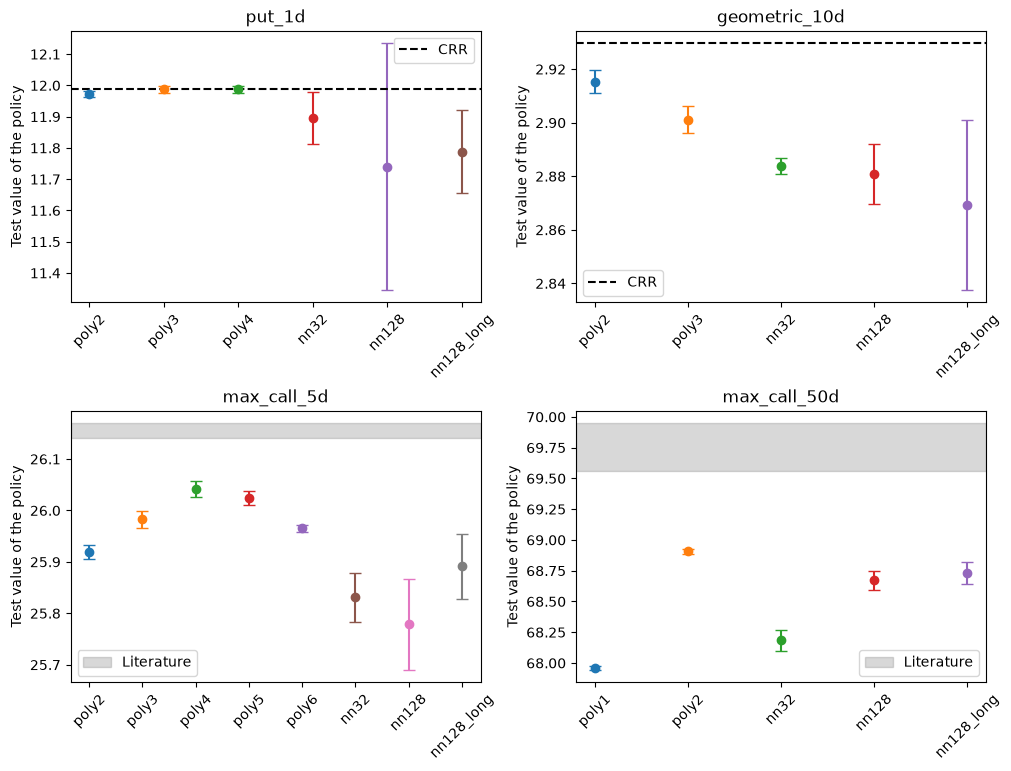

In [15]:
names = list(results)
n_rows = (len(names) + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 3.8 * n_rows), constrained_layout=True,
                         squeeze=False)
for ax, name in zip(axes.flat, names):
    reps = results[name]["repetitions"]
    candidates = list(reps[0]["configs"])
    for i, candidate in enumerate(candidates):
        mean, half = across_repetitions([rep["configs"][candidate]["test_value"] for rep in reps])
        ax.errorbar(i, mean, yerr=half, fmt="o", capsize=4)
    if name in REFERENCES:
        ax.axhline(REFERENCES[name][2000], color="black", linestyle="--", label="CRR")
    if CASES[name]["literature"] is not None:
        ax.axhspan(*CASES[name]["literature"], color="grey", alpha=0.3, label="Literature")
    ax.set_xticks(range(len(candidates)), candidates, rotation=45)
    ax.set_title(name)
    ax.set_ylabel("Test value of the policy")
    ax.legend()
for ax in axes.flat[len(names):]:
    ax.axis("off")
fig.savefig(f"report/fig_policy_values_{M_TRAIN}.pdf", bbox_inches="tight")
plt.show()

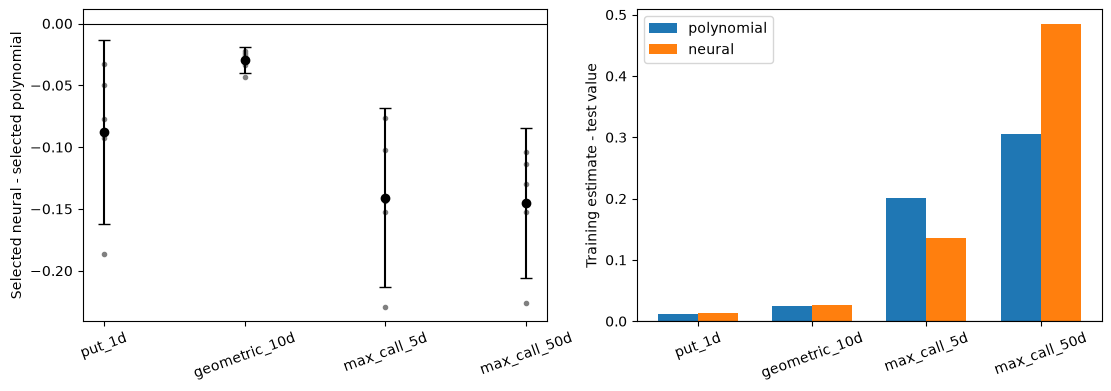

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for i, name in enumerate(names):
    reps = results[name]["repetitions"]
    differences = [rep["difference"]["value"] for rep in reps]
    mean, half = across_repetitions(differences)
    axes[0].plot([i] * len(differences), differences, ".", color="grey")
    axes[0].errorbar(i, mean, yerr=half, fmt="o", color="black", capsize=4)
    for j, family in enumerate(("polynomial", "neural")):
        gaps = [rep["configs"][rep["selected"][family]]["training_value"]
                - rep["configs"][rep["selected"][family]]["test_value"] for rep in reps]
        axes[1].bar(i + (j - 0.5) * 0.35, np.mean(gaps), width=0.35, color=f"C{j}",
                    label=family if i == 0 else None)
for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(range(len(names)), names, rotation=20)
axes[0].set_ylabel("Selected neural - selected polynomial")
axes[1].set_ylabel("Training estimate - test value")
axes[1].legend()
fig.savefig(f"report/fig_comparison_{M_TRAIN}.pdf", bbox_inches="tight")
plt.show()

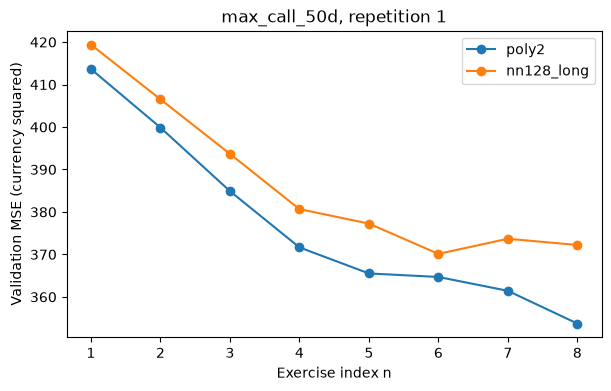

In [17]:
# Held-out regression error by date, for the selected policies of one repetition.
PLOT_CASE, PLOT_REPETITION = names[-1], 0
rep = results[PLOT_CASE]["repetitions"][PLOT_REPETITION]
fig, ax = plt.subplots(figsize=(6, 3.8), constrained_layout=True)
for family in ("polynomial", "neural"):
    candidate = rep["selected"][family]
    diagnostics = sorted(rep["configs"][candidate]["diagnostics"], key=lambda dg: dg["date"])
    mse = [np.nan if dg["validation_mse"] is None else dg["validation_mse"] for dg in diagnostics]
    ax.plot([dg["date"] for dg in diagnostics], mse, "o-", label=candidate)
ax.set_xlabel("Exercise index n")
ax.set_ylabel("Validation MSE (currency squared)")
ax.set_title(f"{PLOT_CASE}, repetition {PLOT_REPETITION + 1}")
ax.legend()
fig.savefig(f"report/fig_validation_mse_{M_TRAIN}.pdf", bbox_inches="tight")
plt.show()

## 8. Effect of the training budget

Each budget has its own results file. This cell reads every available file, whatever the current
settings, and summarizes the selected policies: mean test values, the selected difference with its
Student half-width, and the mean gap between training estimate and test value.

case              M_train  polynomial    neural  difference     +/-  gap poly     +/-  gap neural     +/-
put_1d              10000     11.9851   11.9038     -0.0813  0.0334   -0.0141  0.0762     -0.0399  0.0870
put_1d             100000     11.9884   11.9006     -0.0878  0.0742   +0.0122  0.0153     +0.0134  0.0179
geometric_10d       10000      2.8719    2.8504     -0.0216  0.0379   +0.1445  0.0270     +0.0443  0.0388
geometric_10d      100000      2.9154    2.8857     -0.0296  0.0108   +0.0250  0.0144     +0.0273  0.0190
max_call_5d         10000     25.8874   25.8578     -0.0296  0.0488   +0.1254  0.3562     +0.0456  0.3991
max_call_5d        100000     26.0320   25.8912     -0.1408  0.0724   +0.2004  0.1390     +0.1363  0.1125
max_call_50d        10000     67.9269   68.6828     +0.7558  0.1259   +0.2054  0.1506     +0.8202  0.4897
max_call_50d       100000     68.9066   68.7614     -0.1452  0.0609   +0.3059  0.0645     +0.4845  0.1648
max_call_50d      1000000     68.9933   68.823

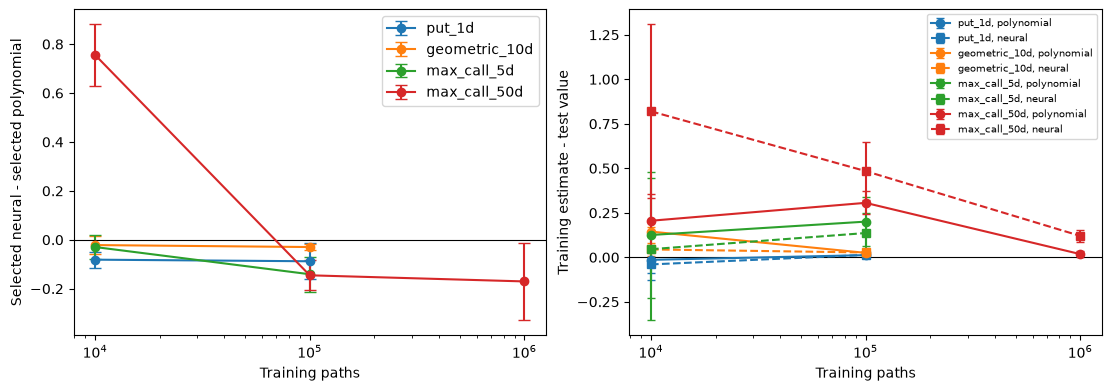

In [18]:
BUDGETS = [10_000, 100_000, 1_000_000]
budget_results = {}
for name in CASES:
    for budget in BUDGETS:
        try:
            budget_results[name, budget] = torch.load(f"results/results_{name}_{budget}.pt", weights_only=False)
        except FileNotFoundError:
            pass


def selected_summary(saved):
    reps = saved["repetitions"]
    summary = {"difference": across_repetitions([rep["difference"]["value"] for rep in reps])}
    for family in ("polynomial", "neural"):
        chosen = [rep["configs"][rep["selected"][family]] for rep in reps]
        summary[family] = across_repetitions([row["test_value"] for row in chosen])
        summary[family + "_gap"] = across_repetitions(
            [row["training_value"] - row["test_value"] for row in chosen])
    return summary


# The saved files must describe the same contract and candidates as the current settings.
for (name, budget), saved in budget_results.items():
    case = saved["settings"]["case"]
    if case["model"] != CASES[name]["model"] or case["degrees"] != CASES[name]["degrees"] \
            or saved["settings"]["networks"] != NETWORKS:
        print(f"Warning: results/results_{name}_{budget}.pt uses other contract parameters or candidates.")

print(f"{'case':<15}{'M_train':>10}{'polynomial':>12}{'neural':>10}{'difference':>12}{'+/-':>8}"
      f"{'gap poly':>10}{'+/-':>8}{'gap neural':>12}{'+/-':>8}")
for (name, budget), saved in budget_results.items():
    s = selected_summary(saved)
    print(f"{name:<15}{budget:>10}{s['polynomial'][0]:>12.4f}{s['neural'][0]:>10.4f}"
          f"{s['difference'][0]:>+12.4f}{s['difference'][1]:>8.4f}"
          f"{s['polynomial_gap'][0]:>+10.4f}{s['polynomial_gap'][1]:>8.4f}"
          f"{s['neural_gap'][0]:>+12.4f}{s['neural_gap'][1]:>8.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for i, name in enumerate(CASES):
    budgets = [budget for budget in BUDGETS if (name, budget) in budget_results]
    if not budgets:
        continue
    rows = [selected_summary(budget_results[name, budget]) for budget in budgets]
    axes[0].errorbar(budgets, [row["difference"][0] for row in rows],
                     yerr=[row["difference"][1] for row in rows],
                     fmt="o-", capsize=4, color=f"C{i}", label=name)
    axes[1].errorbar(budgets, [row["polynomial_gap"][0] for row in rows],
                     yerr=[row["polynomial_gap"][1] for row in rows], fmt="o-", capsize=3,
                     color=f"C{i}", label=f"{name}, polynomial")
    axes[1].errorbar(budgets, [row["neural_gap"][0] for row in rows],
                     yerr=[row["neural_gap"][1] for row in rows], fmt="s--", capsize=3,
                     color=f"C{i}", label=f"{name}, neural")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("Training paths")
    ax.axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Selected neural - selected polynomial")
axes[1].set_ylabel("Training estimate - test value")
axes[0].legend()
axes[1].legend(fontsize=7)
fig.savefig("report/fig_budget.pdf", bbox_inches="tight")
plt.show()

### References

- Longstaff & Schwartz (2001), *Valuing American Options by Simulation: A Simple Least-Squares Approach*.
- Lapeyre & Lelong (2020), [*Neural network regression for Bermudan option pricing*](https://arxiv.org/abs/1907.06474v3).
- Kingma & Ba (2015), [*Adam: A Method for Stochastic Optimization*](https://arxiv.org/abs/1412.6980).